# PCA para explorar la reducción de columnas CLC

Este análisis localiza todas las columnas cuyo nombre comienza por `clc_`. Como las clases CLC son códigos categóricos, primero se aplica codificación one-hot; introducir los códigos directamente como números haría que PCA interpretara distancias ordinales que no necesariamente existen. A continuación se aplica PCA a esas categorías codificadas.

El notebook informa cuántos componentes hacen falta para conservar el 90% y el 95% de la varianza de las columnas CLC, muestra la varianza acumulada y permite inspeccionar qué columnas originales contribuyen más a los componentes. Si el CSV supera 20.000 filas, se ajusta PCA sobre una muestra reproducible de 20.000 filas para mantener el análisis manejable. El resultado es exploratorio; la decisión final depende del modelo y de la interpretación que se quiera conservar.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.decomposition import PCA
from IPython.display import display

csv_path = Path.home() / 'Desktop' / 'wildfires-project-development' / 'data' / 'processed' / 'enriched' / 'firms_spain_final.csv'
if not csv_path.exists():
    raise FileNotFoundError(f'No se encontró el CSV: {csv_path}')
df = pd.read_csv(csv_path, low_memory=False)
clc_cols = [col for col in df.columns if col.lower().startswith('clc_')]
if not clc_cols:
    raise ValueError('No se encontraron columnas cuyo nombre empiece por clc_.')

print(f'Filas en el CSV: {len(df):,}')
print(f'Columnas CLC detectadas ({len(clc_cols)}): {clc_cols}')
display(pd.DataFrame({
    'tipo': df[clc_cols].dtypes.astype(str),
    'valores_distintos': df[clc_cols].nunique(dropna=True),
    'faltantes': df[clc_cols].isna().sum()
}))

Filas en el CSV: 35,284
Columnas CLC detectadas (10): ['clc_class', 'clc_class_N', 'clc_class_S', 'clc_class_W', 'clc_class_E', 'clc_class_NW', 'clc_class_NE', 'clc_class_SW', 'clc_class_SE', 'clc_uniform_surroundings']


,tipo,valores_distintos,faltantes
clc_class,int64,9,0
clc_class_N,int64,10,0
clc_class_S,int64,10,0
clc_class_W,int64,10,0
clc_class_E,int64,10,0
clc_class_NW,int64,10,0
clc_class_NE,int64,10,0
clc_class_SW,int64,10,0
clc_class_SE,int64,10,0
clc_uniform_surroundings,bool,2,0


## Codificación y ajuste de PCA

Los faltantes se conservan como una categoría explícita (`SIN_DATO`). El codificador se ajusta con todas las filas para conocer las categorías presentes; PCA se ajusta con una muestra de hasta 20.000 filas. One-hot produce una matriz dispersa primero y se convierte a matriz densa solo para la muestra usada por PCA.

In [2]:
MAX_FILAS_PCA = 20_000

# Convertir todas las clases a texto previene que etiquetas mixtas causen errores.
X_cat = df[clc_cols].astype('string').fillna('SIN_DATO').astype(str)
try:
    encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
except TypeError:  # compatibilidad con versiones anteriores de scikit-learn
    encoder = OneHotEncoder(handle_unknown='ignore', sparse=True)

encoder.fit(X_cat)
n_fit = min(len(X_cat), MAX_FILAS_PCA)
X_sample_cat = X_cat.sample(n=n_fit, random_state=42)
X_sample_sparse = encoder.transform(X_sample_cat)
X_sample = X_sample_sparse.toarray()

n_components = min(X_sample.shape[0], X_sample.shape[1])
pca = PCA(n_components=n_components, svd_solver='full', random_state=42)
scores = pca.fit_transform(X_sample)
explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

def components_for(threshold):
    reached = np.flatnonzero(cumulative >= threshold)
    return int(reached[0] + 1) if len(reached) else None

n90, n95 = components_for(0.90), components_for(0.95)
n_encoded = X_sample.shape[1]
print(f'Columnas CLC originales: {len(clc_cols)}')
print(f'Variables one-hot: {n_encoded}')
print(f'Filas usadas para ajustar PCA: {n_fit:,}')
print(f'Componentes para >=90% de varianza: {n90}')
print(f'Componentes para >=95% de varianza: {n95}')
if n95 is not None:
    print(f'Reducción de {n_encoded} variables one-hot a {n95} componentes para conservar >=95% de varianza.')

variance_table = pd.DataFrame({
    'componente': np.arange(1, len(explained) + 1),
    'varianza_individual': explained,
    'varianza_acumulada': cumulative
})
display(variance_table.head(20))

Columnas CLC originales: 10
Variables one-hot: 91
Filas usadas para ajustar PCA: 20,000
Componentes para >=90% de varianza: 20
Componentes para >=95% de varianza: 33
Reducción de 91 variables one-hot a 33 componentes para conservar >=95% de varianza.


,componente,varianza_individual,varianza_acumulada
0,1,0.197320,0.197320
1,2,0.176209,0.373529
2,3,0.127317,0.500847
3,4,0.096372,0.597218
4,5,0.083699,0.680918
5,6,0.066014,0.746932
6,7,0.052375,0.799307
7,8,0.016150,0.815457
8,9,0.014158,0.829614
9,10,0.010355,0.839970


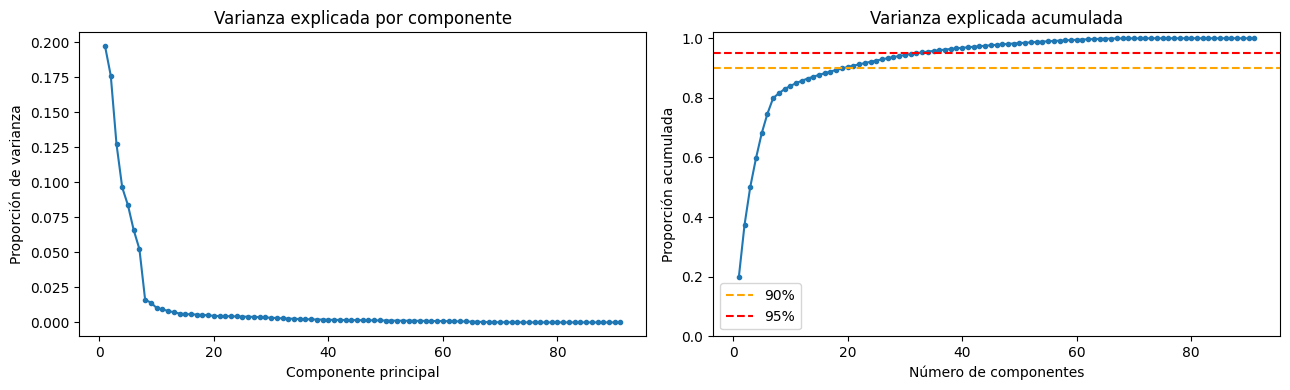

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(variance_table['componente'], variance_table['varianza_individual'], marker='o', ms=3)
axes[0].set(title='Varianza explicada por componente', xlabel='Componente principal', ylabel='Proporción de varianza')
axes[1].plot(variance_table['componente'], variance_table['varianza_acumulada'], marker='o', ms=3)
axes[1].axhline(.90, color='orange', linestyle='--', label='90%')
axes[1].axhline(.95, color='red', linestyle='--', label='95%')
axes[1].set(title='Varianza explicada acumulada', xlabel='Número de componentes', ylabel='Proporción acumulada', ylim=(0, 1.02))
axes[1].legend()
plt.tight_layout()
plt.show()

## Contribuciones de las columnas CLC

Para cada componente se suman las magnitudes absolutas de las cargas de sus categorías one-hot, agrupadas por la columna CLC original. Es una ayuda para interpretar qué campos aportan más a cada componente; las cargas individuales dependen de la categoría concreta. La última celda deja en memoria las puntuaciones PCA de la muestra, reducidas al menor número de componentes que conserva el 95% (o todos si no se alcanza ese umbral).

In [4]:
encoded_names = encoder.get_feature_names_out(clc_cols)
# El orden de get_feature_names_out sigue categorías_ por cada columna.
encoded_to_source = []
for col, categories in zip(clc_cols, encoder.categories_):
    encoded_to_source.extend([col] * len(categories))

n_show = min(5, pca.components_.shape[0])
loading_rows = []
for pc in range(n_show):
    abs_loadings = np.abs(pca.components_[pc])
    summary = pd.Series(abs_loadings).groupby(encoded_to_source).sum().sort_values(ascending=False)
    for source_col, value in summary.head(5).items():
        loading_rows.append({'componente': f'PC{pc+1}', 'columna_CLC': source_col, 'suma_cargas_absolutas': value})
display(pd.DataFrame(loading_rows))

# DataFrame reducido de la muestra usada por PCA.
n_keep = n95 if n95 is not None else scores.shape[1]
reduced_sample = pd.DataFrame(
    scores[:, :n_keep],
    index=X_sample_cat.index,
    columns=[f'PC{i+1}' for i in range(n_keep)]
)
print(f'Muestra reducida: {reduced_sample.shape[0]:,} filas x {reduced_sample.shape[1]} componentes')
reduced_sample.head()

,componente,columna_CLC,suma_cargas_absolutas
0,PC1,clc_class,0.568691
1,PC1,clc_class_E,0.549011
2,PC1,clc_class_S,0.545039
3,PC1,clc_class_W,0.543994
4,PC1,clc_class_N,0.541085
5,PC2,clc_class,0.630345
6,PC2,clc_class_E,0.613067
7,PC2,clc_class_W,0.611607
8,PC2,clc_class_S,0.611092
9,PC2,clc_class_N,0.610677


Muestra reducida: 20,000 filas x 33 componentes


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC24,PC25,PC26,PC27,PC28,PC29,PC30,PC31,PC32,PC33
28899,-0.430114,2.443742,-1.214606,0.386499,0.020778,-0.118009,0.090869,0.002322,-0.005842,0.015487,...,0.003056,-0.001789,0.001992,-0.000768,-0.006451,0.000359,0.005215,0.001332,-0.000587,-0.005207
14034,-1.935399,-1.497962,-0.861706,0.296849,-0.015041,-0.131333,0.332374,0.002634,-0.001579,0.055073,...,-0.006258,0.012344,0.009226,0.001143,0.002245,0.001820,-0.021456,-0.010600,-0.009121,0.009961
5337,-0.718803,-0.386165,0.411317,-1.095026,1.441867,-0.376395,-0.893792,0.376662,-0.097228,-0.506488,...,-0.081029,0.332508,0.351366,-0.040185,0.241305,-0.056632,0.080260,0.077223,0.084546,0.156204
647,-0.596555,-0.079626,0.530781,-1.027336,1.755521,-0.755615,0.455186,0.274206,0.136277,-0.148096,...,-0.237893,0.302136,0.018351,-0.118203,-0.108738,0.036998,-0.435352,-0.212341,-0.215187,0.141094
1270,-1.935399,-1.497962,-0.861706,0.296849,-0.015041,-0.131333,0.332374,0.002634,-0.001579,0.055073,...,-0.006258,0.012344,0.009226,0.001143,0.002245,0.001820,-0.021456,-0.010600,-0.009121,0.009961
